# Projeto Final: Análise de Mobilidade e Transporte Metropolitano

**Aluno:** Felipe Alexandre Alves da Silva
**Disciplina:** Modelos Descritivos
**Professor:** Matheus Lacerda


---

## 📌 Objetivo
Este projeto tem como objetivo aplicar técnicas de **Aprendizado Não Supervisionado (Clusterização)** para analisar dados de mobilidade urbana em Regiões Metropolitanas brasileiras. 

A partir da base de dados **PEMOB 2025 (Pesquisa de Mobilidade Urbana)**, buscaremos agrupar as regiões com características operacionais e financeiras semelhantes, gerando insights estratégicos que possam embasar decisões de gestores públicos e privados do setor de transporte.

## 🎯 Problemática
**"Quais são os diferentes perfis operacionais das Regiões Metropolitanas brasileiras e como podemos agrupá-las para direcionar investimentos e políticas públicas de mobilidade?"**

## 1. Importação de Bibliotecas e Configurações

Nesta etapa, importamos as bibliotecas essenciais para análise de dados, visualização e modelagem de clusterização.

In [59]:
# 1. Importações e Configurações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
%matplotlib inline

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2. Carregamento e Entendimento dos Dados

A base utilizada é o **PEMOB 2025** (Pesquisa de Mobilidade Urbana), que contém informações sobre infraestrutura, operação, demanda, finanças e tecnologia do transporte público nas Regiões Metropolitanas brasileiras.

A base possui um cabeçalho mesclado, por isso a leitura é feita a partir da segunda linha (`header=1`). Também realizamos a limpeza de valores textuais que representam nulos (`NA`, `NR`, `N/E`).

In [60]:
# 2. Carregando os dados brutos
caminho_base = '../data/raw/pemob_metropolitana_2025.xlsx'

df = pd.read_excel(caminho_base, header=1)
df = df.rename(columns={df.columns[0]: 'UF', df.columns[1]: 'Regiao_Metropolitana'})
df = df.replace(['NA', 'NR', 'N/E', 'Nenhum', ' '], np.nan)

print(f"✅ Base carregada: {df.shape[0]} Regiões Metropolitanas e {df.shape[1]} colunas.")
print("\n📋 Primeiras linhas da base:")
display(df[['UF', 'Regiao_Metropolitana']].head(10))

✅ Base carregada: 29 Regiões Metropolitanas e 344 colunas.

📋 Primeiras linhas da base:


,UF,Regiao_Metropolitana
0,AL,Região Metropolitana de Maceió
1,AM,Região Metropolitana de Manaus
2,BA,Região Metropolitana de Salvador
3,ES,Região Metropolitana da Grande Vitória
4,GO,Região Metropolitana de Goiânia
5,MG,Região Metropolitana de Belo Horizonte
6,PE,Região Metropolitana de Recife
7,PI,Região Integrada de Desenvolvimento da Grande ...
8,PR,Região Metropolitana de Curitiba
9,PR,Região Metropolitana de Londrina


## 3. Seleção, Renomeação e Padronização das Variáveis

A base original possui **344 colunas**, o que é inviável para algoritmos de clusterização. Selecionamos **5 variáveis** que representam as dimensões fundamentais da mobilidade:

| Dimensão | Variável Original | Nome Renomeado | Descrição |
|----------|-------------------|----------------|-----------|
| Infraestrutura | `1.2.1.A` | Terminais | Nº de terminais rodoviários |
| Infraestrutura | `1.3.1.A` | Frota_Onibus | Frota de ônibus operacionais |
| Operação | `1.4.1` | Km_Percorrida | Km percorrida por ônibus em 2024 |
| Qualidade | `2.1.1` | Idade_Frota | Idade média da frota (anos) |
| Demanda | `3.2.1.A` | Passageiros_Comuns | Nº de passageiros comuns |

In [61]:
# 3. Seleção, Renomeação e Limpeza (tudo em ordem correta)

# 3.1 - Códigos originais e nomes que vamos usar
codigos_originais = ['1.2.1.A', '1.3.1.A', '1.4.1', '2.1.1', '3.2.1.A']
nomes_novos = ['Terminais', 'Frota_Onibus', 'Km_Percorrida', 'Idade_Frota', 'Passageiros_Comuns']

# 3.2 - Seleciona as colunas da base original
df_cluster = df[['UF', 'Regiao_Metropolitana'] + codigos_originais].copy()

# 3.3 - Renomeia IMEDIATAMENTE para nomes legíveis
df_cluster.columns = ['UF', 'Regiao_Metropolitana'] + nomes_novos

# 3.4 - Define a lista de variáveis que vamos usar
variaveis_interesse = nomes_novos

# 3.5 - Converte para numérico e remove nulos
for col in variaveis_interesse:
    df_cluster[col] = pd.to_numeric(df_cluster[col], errors='coerce')

df_cluster = df_cluster.dropna()

print(f"✅ Base limpa: {df_cluster.shape[0]} RMs e {df_cluster.shape[1]} colunas")
print("\n📊 Resumo estatístico:")
display(df_cluster[variaveis_interesse].describe().round(2))

✅ Base limpa: 22 RMs e 7 colunas

📊 Resumo estatístico:


,Terminais,Frota_Onibus,Km_Percorrida,Idade_Frota,Passageiros_Comuns
count,22.00,22.00,2.200000e+01,22.00,2.200000e+01
mean,7.68,824.64,5.717466e+07,12.43,3.939367e+08
std,8.95,1191.65,9.268718e+07,4.55,8.528535e+08
min,1.00,17.00,7.598500e+04,5.00,5.234354e+05
25%,1.00,45.50,1.206586e+06,8.00,5.115436e+06
50%,1.00,226.00,1.712713e+07,12.75,3.135176e+07
75%,14.50,1234.50,7.000498e+07,16.50,2.977220e+08
max,26.00,3712.00,3.611663e+08,21.00,3.578830e+09


## 4. Padronização das Variáveis (StandardScaler)

**Por que padronizar?**

Algoritmos baseados em distância (K-Means, Hierárquico) são **sensíveis à escala**. Observe no resumo estatístico:

- **Passageiros** estão na casa dos **milhões**
- **Idade da frota** está na casa das **dezenas**
- **Terminais** estão na casa das **unidades**

Sem padronização, a variável "Passageiros" dominaria completamente o cálculo da distância Euclidiana. Aplicamos então o **StandardScaler**, que transforma os dados para **média 0 e desvio padrão 1**.

In [62]:
# 4. Padronização (versão atualizada - DF_CLUSTER já renomeado)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster[variaveis_interesse])

df_scaled = pd.DataFrame(df_scaled, columns=variaveis_interesse)
df_scaled['Regiao_Metropolitana'] = df_cluster['Regiao_Metropolitana'].values
df_scaled['UF'] = df_cluster['UF'].values

print("✅ Padronização atualizada!")
print("\n📋 Colunas do df_scaled:")
print(list(df_scaled.columns))
display(df_scaled[variaveis_interesse].describe().round(4))

✅ Padronização atualizada!

📋 Colunas do df_scaled:
['Terminais', 'Frota_Onibus', 'Km_Percorrida', 'Idade_Frota', 'Passageiros_Comuns', 'Regiao_Metropolitana', 'UF']


,Terminais,Frota_Onibus,Km_Percorrida,Idade_Frota,Passageiros_Comuns
count,22.0000,22.0000,22.0000,22.0000,22.0000
mean,0.0000,0.0000,-0.0000,0.0000,0.0000
std,1.0235,1.0235,1.0235,1.0235,1.0235
min,-0.7640,-0.6937,-0.6305,-1.6703,-0.4721
25%,-0.7640,-0.6692,-0.6180,-0.9956,-0.4666
50%,-0.7640,-0.5142,-0.4422,0.0726,-0.4351
75%,0.7796,0.3520,0.1417,0.9159,-0.1155
max,2.0945,2.4800,3.3569,1.9279,3.8223


## 5. Clusterização com K-Means - Método do Cotovelo

Agora vamos aplicar o algoritmo **K-Means** para agrupar as Regiões Metropolitanas.

Mas antes, precisamos definir o **número ideal de clusters (K)**. Para isso, utilizaremos o **Método do Cotovelo (Elbow Method)**, que analisa a **inércia** (soma das distâncias ao quadrado dos pontos ao centróide mais próximo) para diferentes valores de K.

**A lógica:** A inércia sempre diminui conforme aumentamos K, mas chega um ponto onde a redução se torna marginal. Esse "cotovelo" no gráfico indica o K ideal.

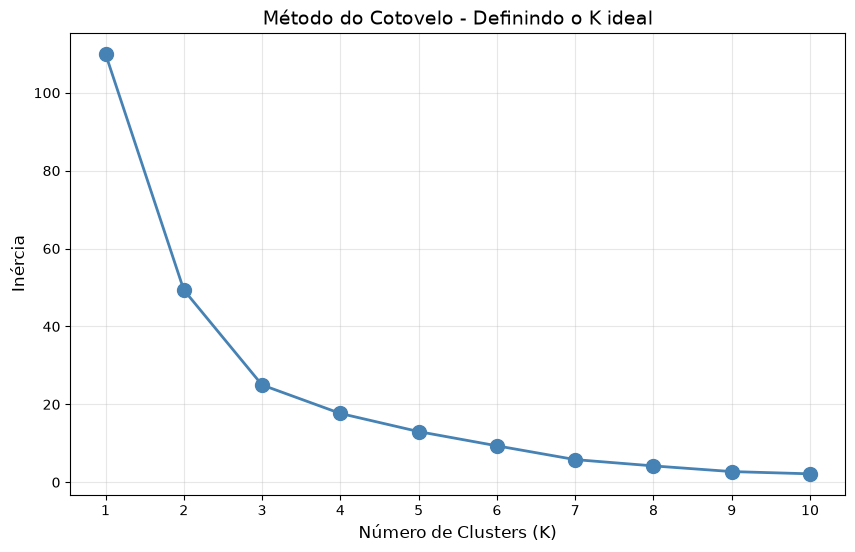

In [ ]:
# 6. Método do Cotovelo (Elbow Method)
inercia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled[variaveis_interesse])
    inercia.append(kmeans.inertia_)

# Plotando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(K_range, inercia, marker='o', linestyle='-', color='steelblue', linewidth=2, markersize=10)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inércia', fontsize=12)
plt.title('Método do Cotovelo - Definindo o K ideal', fontsize=14)
plt.xticks(K_range)
plt.grid(alpha=0.3)
plt.show()

## 6. Aplicação do K-Means com K=3

Com base no gráfico do cotovelo, escolhemos **K=3** como o número ideal de clusters. Isso significa que vamos agrupar as 22 Regiões Metropolitanas em 3 perfis distintos de mobilidade.

Vamos treinar o modelo e visualizar a distribuição das RMs em cada grupo.

In [64]:
# 6. Aplicando K-Means com K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_scaled['Cluster'] = kmeans_final.fit_predict(df_scaled[variaveis_interesse])

# Adicionando os clusters de volta ao df_cluster
df_cluster['Cluster'] = df_scaled['Cluster'].values

print("✅ K-Means aplicado com sucesso!")
print(f"\n📊 Distribuição das RMs por cluster:")
print(df_cluster['Cluster'].value_counts().sort_index())

print("\n📈 Média das variáveis por cluster:")
display(df_cluster.groupby('Cluster')[variaveis_interesse].mean().round(2))

print("\n📋 Regiões Metropolitanas em cada cluster:")
for cluster in sorted(df_cluster['Cluster'].unique()):
    rms = df_cluster[df_cluster['Cluster'] == cluster]['Regiao_Metropolitana'].tolist()
    print(f"\n🔹 Cluster {cluster} ({len(rms)} RMs):")
    for rm in rms:
        print(f"   - {rm}")

✅ K-Means aplicado com sucesso!

📊 Distribuição das RMs por cluster:
Cluster
0     7
1    13
2     2
Name: count, dtype: int64

📈 Média das variáveis por cluster:


,Terminais,Frota_Onibus,Km_Percorrida,Idade_Frota,Passageiros_Comuns
Cluster,,,,,
0,18.14,1326.86,8.728794e+07,8.93,3.895403e+08
1,1.31,113.31,5.434191e+06,15.15,2.794063e+07
2,12.50,3690.50,2.880912e+08,7.00,2.788299e+09



📋 Regiões Metropolitanas em cada cluster:

🔹 Cluster 0 (7 RMs):
   - Região Metropolitana de Salvador
   - Região Metropolitana da Grande Vitória
   - Região Metropolitana de Goiânia
   - Região Metropolitana de Belo Horizonte
   - Região Metropolitana de Recife
   - Região Metropolitana de Curitiba
   - Região Metropolitana de Natal

🔹 Cluster 1 (13 RMs):
   - Região Metropolitana de Maceió
   - Região Metropolitana de Manaus
   - Região Metropolitana da Foz do Rio Itajaí
   - Região Metropolitana de Chapecó
   - Região Metropolitana de Florianópolis
   - Região Metropolitana de Lages
   - Região Metropolitana de Tubarão
   - Região Metropolitana do Alto Vale do Itajaí
   - Região Metropolitana do Contestado
   - Região Metropolitana do Extremo Oeste
   - Região Metropolitana do Norte/Nordeste Catarinense
   - Região Metropolitana do Vale do Itajaí
   - Região Metropolitana de Campinas

🔹 Cluster 2 (2 RMs):
   - Região Metropolitana do Rio de Janeiro
   - Região Metropolitana de São 

## 7. Visualização dos Clusters

Vamos visualizar os clusters em um gráfico 2D, usando as duas variáveis mais representativas: **Frota de Ônibus** e **Passageiros Comuns**. Isso nos permite ver a separação dos grupos no espaço.

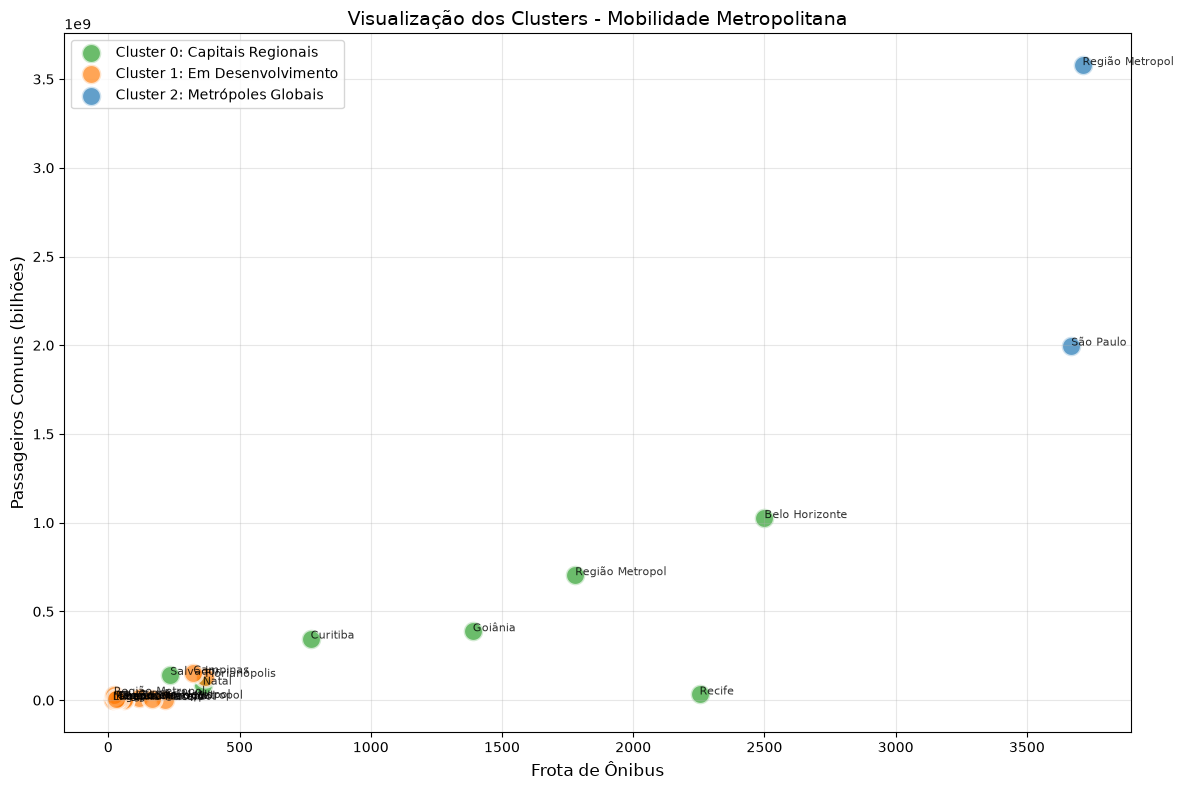

In [65]:
# 7. Visualização dos clusters em 2D
plt.figure(figsize=(12, 8))
cores = {0: '#2ca02c', 1: '#ff7f0e', 2: '#1f77b4'}
nomes_clusters = {0: 'Capitais Regionais', 1: 'Em Desenvolvimento', 2: 'Metrópoles Globais'}

for cluster in sorted(df_cluster['Cluster'].unique()):
    subset = df_cluster[df_cluster['Cluster'] == cluster]
    plt.scatter(
        subset['Frota_Onibus'],
        subset['Passageiros_Comuns'],
        c=cores[cluster],
        s=200,
        alpha=0.7,
        edgecolors='white',
        linewidth=2,
        label=f'Cluster {cluster}: {nomes_clusters[cluster]}'
    )
    for _, row in subset.iterrows():
        plt.annotate(
            row['Regiao_Metropolitana'].replace('Região Metropolitana de ', '')[:15],
            (row['Frota_Onibus'], row['Passageiros_Comuns']),
            fontsize=8,
            alpha=0.8
        )

plt.xlabel('Frota de Ônibus', fontsize=12)
plt.ylabel('Passageiros Comuns (bilhões)', fontsize=12)
plt.title('Visualização dos Clusters - Mobilidade Metropolitana', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Avaliação dos Clusters - Silhouette Score

O **Silhouette Score** mede a qualidade do agrupamento, variando de **-1 a 1**:
- **Próximo de 1:** clusters bem separados e coesos ✅
- **Próximo de 0:** clusters sobrepostos ⚠️
- **Próximo de -1:** pontos atribuídos ao cluster errado ❌

Vamos calcular o score para K=3.

In [66]:
# 8. Silhouette Score
sil_score = silhouette_score(df_scaled[variaveis_interesse], df_scaled['Cluster'])

print(f"📊 Silhouette Score para K=3: {sil_score:.4f}")
print("\n📖 Interpretação:")
if sil_score > 0.5:
    print("   ✅ Estrutura forte e bem definida")
elif sil_score > 0.3:
    print("   ✅ Estrutura razoável - clusters bem separados")
elif sil_score > 0.1:
    print("   ⚠️ Estrutura fraca - pode haver sobreposição")
else:
    print("   ❌ Estrutura inexistente")

📊 Silhouette Score para K=3: 0.5383

📖 Interpretação:
   ✅ Estrutura forte e bem definida


## 9. Clusterização Hierárquica - Dendrograma

Para validar nossos resultados do K-Means, vamos aplicar a **Clusterização Hierárquica Aglomerativa**, que constrói uma árvore de similaridade entre as RMs.

O **Dendrograma** nos mostra visualmente a distância entre os agrupamentos, permitindo confirmar se 3 clusters é realmente a escolha correta.

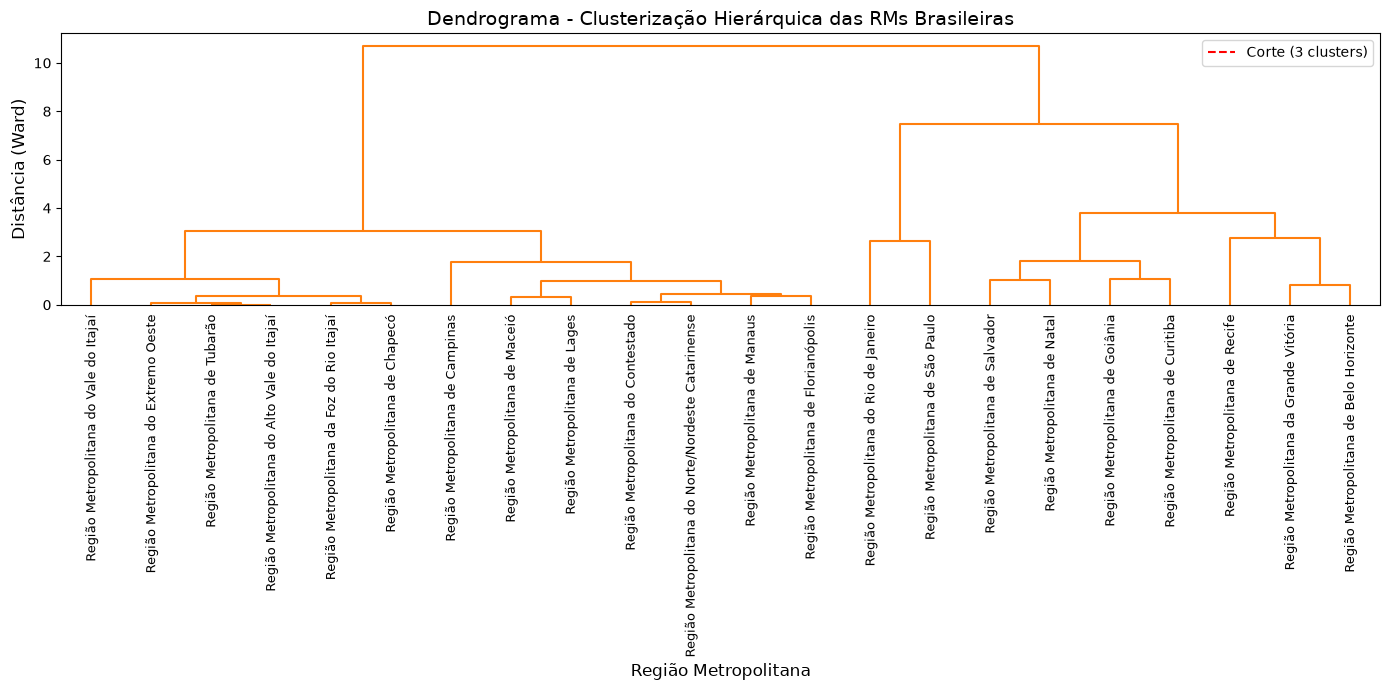

In [67]:
# 9. Dendrograma - Clusterização Hierárquica
plt.figure(figsize=(14, 7))

# Aplicando o linkage (método ward + distância euclidiana)
Z = linkage(df_scaled[variaveis_interesse], method='ward', metric='euclidean')

# Gerando o dendrograma
dendrogram(
    Z,
    labels=df_cluster['Regiao_Metropolitana'].values,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=15
)

plt.title('Dendrograma - Clusterização Hierárquica das RMs Brasileiras', fontsize=14)
plt.xlabel('Região Metropolitana', fontsize=12)
plt.ylabel('Distância (Ward)', fontsize=12)
plt.axhline(y=15, color='red', linestyle='--', linewidth=1.5, label='Corte (3 clusters)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 10. Salvando os Resultados

Vamos salvar a base final com os clusters atribuídos para usar nos slides e no relatório final.

In [68]:
# 10. Salvando o resultado final
caminho_saida = '../data/processed/mobilidade_clusterizada.csv'
df_cluster.to_csv(caminho_saida, index=False, encoding='utf-8-sig')

print(f"✅ Resultados salvos em: {caminho_saida}")
print(f"\n📋 Resumo Final:")
print(f"   Total de RMs analisadas: {len(df_cluster)}")
print(f"   Número de clusters: {df_cluster['Cluster'].nunique()}")
print(f"   Silhouette Score: {sil_score:.4f}")

print("\n📊 Distribuição das RMs por cluster:")
for cluster in sorted(df_cluster['Cluster'].unique()):
    n = len(df_cluster[df_cluster['Cluster'] == cluster])
    pct = (n / len(df_cluster)) * 100
    print(f"   Cluster {cluster}: {n} RMs ({pct:.1f}%)")

✅ Resultados salvos em: ../data/processed/mobilidade_clusterizada.csv

📋 Resumo Final:
   Total de RMs analisadas: 22
   Número de clusters: 3
   Silhouette Score: 0.5383

📊 Distribuição das RMs por cluster:
   Cluster 0: 7 RMs (31.8%)
   Cluster 1: 13 RMs (59.1%)
   Cluster 2: 2 RMs (9.1%)
